In [1]:
!pip install shap xgboost networkx nltk seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import shap
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving bot_detection_data.csv to bot_detection_data.csv


,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


In [23]:
df.columns = df.columns.str.lower().str.strip()

# Rename for easier coding
df.rename(columns={
    'user id': 'user_id',
    'retweet count': 'retweet_count',
    'mention count': 'mention_count',
    'follower count': 'follower_count',
    'bot label': 'label',
    'created at': 'created_at',
    'favorite count': 'favorite_count'
}, inplace=True)

print(df.columns)

Index(['user_id', 'username', 'tweet', 'retweet_count', 'mention_count',
       'follower_count', 'verified', 'label', 'location', 'created_at',
       'hashtags', 'time_diff', 'timing_std', 'timing_regular_score',
       'favorite_count', 'engagement', 'engagement_z', 'burst_flag',
       'sentiment', 'sentiment_std', 'text_length', 'length_std',
       'follower_friend_ratio', 'tweet_frequency', 'avg_time_between_tweets'],
      dtype='object')


In [24]:
df['engagement'] = df['retweet_count'] + df['favorite_count']

df['engagement_ratio'] = df['engagement'] / (df['follower_count'] + 1)

In [25]:
df['mention_ratio'] = df['mention_count'] / (df['follower_count'] + 1)

df['verified'] = df['verified'].astype(int)

In [26]:
df['text_length'] = df['tweet'].apply(len)

df['hashtag_count'] = df['hashtags'].astype(str).apply(lambda x: len(x.split(',')))

df['caps_ratio'] = df['tweet'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))

In [27]:
features = [
    'retweet_count',
    'favorite_count',
    'engagement_ratio',
    'mention_ratio',
    'follower_count',
    'verified',
    'text_length',
    'hashtag_count',
    'caps_ratio'
]

X = df[features]
y = df['label']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.49      0.49      0.49      4973
           1       0.50      0.50      0.50      5027

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.50      0.50      0.50     10000

ROC-AUC: 0.49318166117723994


In [36]:
df['bot_probability'] = model.predict_proba(X_scaled)[:,1]

df['authenticity_score'] = 1 - df['bot_probability']

df[['user_id','bot_probability','authenticity_score']].head()

,user_id,bot_probability,authenticity_score
31668,100025,0.493778,0.506222
32720,100033,0.421274,0.578726
42646,100040,0.338599,0.661401
1914,100053,0.499327,0.500673
5564,100066,0.219177,0.780823


In [37]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)

df['anomaly_label'] = iso.fit_predict(X_scaled)

df['coordinated_anomaly'] = (df['anomaly_label'] == -1).astype(int)

df[['user_id','coordinated_anomaly']].head()

,user_id,coordinated_anomaly
31668,100025,0
32720,100033,0
42646,100040,1
1914,100053,0
5564,100066,0


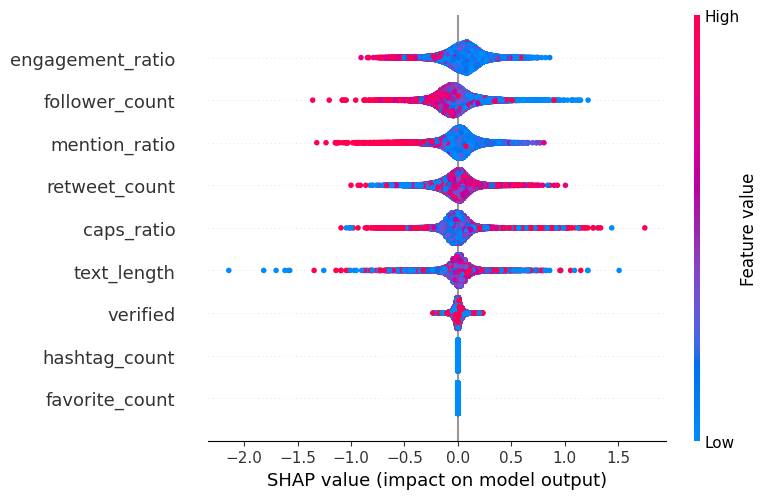

In [38]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X_scaled)

shap.summary_plot(shap_values, X)